# Project 3 — Pandas frequency tables of token lengths

**Chapter 2 · Tokenization** · pp. 31–34

Measure how long GPT-2 tokens are (in characters) and study the distribution of those lengths — first for one paragraph, then across the 10 Project Gutenberg books — using pandas frequency tables and seaborn.

In [1]:
import requests

import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, ScalarFormatter, NullFormatter

In [2]:
### matplotlib adjustments
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

plt.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top":   False,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "savefig.dpi": 300,
})

# **Part 1: Lengths of Stravinsky tokens**

In [3]:
# GPT2 tokenizer
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")

/Users/johnmachado/Desktop/50 ML Projects to Understand LLMs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# https://en.wikipedia.org/wiki/Pulcinella_(ballet)
txt = "Pulcinella is a 21-section ballet by Igor Stravinsky with arias for soprano, tenor and bass vocal soloists, and two sung trios. It is based on the 18th-century play Quatre Polichinelles semblables, or Four similar Pulcinellas, revolving around a stock character from commedia dell'arte. The work premiered at the Paris Opera on 15 May 1920 under the baton of Ernest Ansermet. The central dancer, Léonide Massine, created both the libretto and the choreography, while Pablo Picasso designed the costumes and sets. The ballet was commissioned by Sergei Diaghilev, impresario of the Ballets Russes. A complete performance takes 35–40 minutes. Stravinsky revised the score in 1965."

tokens = tokenizer.encode(txt)
unique_tokens = set(tokens)
print(f"There are {len(txt.split())} words and {len(tokens)} tokens ({len(unique_tokens)} of which are unique).")



There are 104 words and 174 tokens (129 of which are unique).


In [5]:
# qualitative confirmation
decoded_tokens = tokenizer.decode(tokens)
print(decoded_tokens)

# quantitative confirmation
print(f"\nAre they the same? --> {decoded_tokens == txt}")

Pulcinella is a 21-section ballet by Igor Stravinsky with arias for soprano, tenor and bass vocal soloists, and two sung trios. It is based on the 18th-century play Quatre Polichinelles semblables, or Four similar Pulcinellas, revolving around a stock character from commedia dell'arte. The work premiered at the Paris Opera on 15 May 1920 under the baton of Ernest Ansermet. The central dancer, Léonide Massine, created both the libretto and the choreography, while Pablo Picasso designed the costumes and sets. The ballet was commissioned by Sergei Diaghilev, impresario of the Ballets Russes. A complete performance takes 35–40 minutes. Stravinsky revised the score in 1965.

Are they the same? --> True


In [6]:
# loop through tokens and print out their lengths
token_lens = [len(tokenizer.decode(t)) for t in tokens]
print(token_lens[9])
print(tokenizer.decode(tokens[9]))

7
section


In [7]:
# create a pandas dataframe
df = pd.DataFrame({"token": tokens, "length": token_lens})
df.head()

,token,length
0,47,1
1,377,2
2,66,1
3,500,3
4,8466,3


In [8]:
# frequency table: for each distinct token length, how many tokens have that length.
# returns a Series (index = the length, values = the count), sorted most-common first.
val_counts = df["length"].value_counts()
val_counts


length
4     38
3     36
1     25
2     23
5     19
6     11
7      9
8      5
10     3
9      3
13     1
12     1
Name: count, dtype: int64

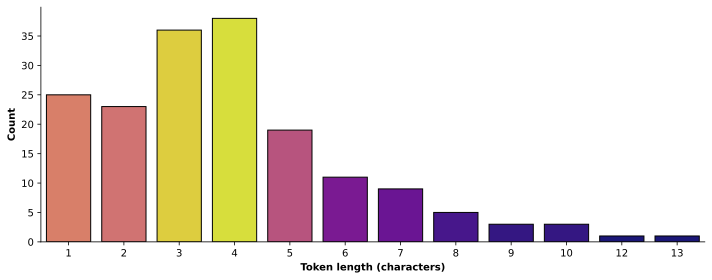

In [9]:
# specify figure size
plt.figure(figsize=(10, 4))

# draw the bar plot
sns.barplot(
    x=val_counts.index, 
    y=val_counts.values, 
    edgecolor="k", 
    hue=val_counts.values,
    palette="plasma",
    legend=False)

# adjustments
plt.gca().set(
    xlabel="Token length (characters)",
    ylabel="Count"
)

plt.tight_layout()
plt.savefig("images/ch2-proj3-pt1.png")
plt.show()


**How to read this chart:** each bar is a token *length* (in characters), and its height is **how many of the paragraph's 174 tokens have that length**. So the length-4 bar at 38 means 38 of the tokens are 4 characters long; the length-1 bar at 25 means 25 tokens are a single character. The bar heights add up to 174 — the total token count. It says nothing about *which* tokens or whether any repeat; only how token lengths are distributed.

**Example — the 38 length-4 tokens are 26 *different* tokens, not one repeated.** Two of them from this very paragraph:

- token id `262` -> `" the"`  (space + "the" = 4 characters)
- token id `290` -> `" and"`  (space + "and" = 4 characters)

Both land in the same length-4 bar because they share a *length*, even though they are completely different tokens. (GPT-2 folds the leading space into the token, which is why ` the` counts as 4, not 3.)

# **Part 2: Distributions of book token lengths**

In [10]:
# all books have the same url format;
# they are unique by numerical code
baseurl = "https://www.gutenberg.org/cache/epub/"

bookurls = [
    # code       title
    ["84", "Frankenstein"],
    ["64317", "GreatGatsby"],
    ["11", "AliceWonderland"],
    ["1513", "RomeoJuliet"],
    ["76", "HuckFinn"],
    ["219", "HeartDarkness"],
    ["2591", "GrimmsTales"],
    ["2148", "EdgarAllenPoe"],
    ["36", "WarOfTheWorlds"],
    ["829", "GulliversTravels"]
]


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (114213 > 1024). Running this sequence through the model will result in indexing errors


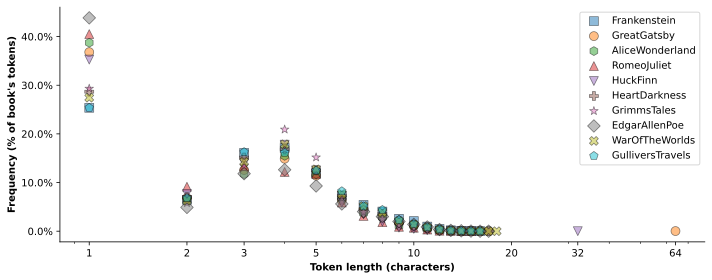

In [11]:
# initialize
plt.figure(figsize=(10, 4))

markersymbols = "soh^vP*DXp"

# loop over books
for i, (code, title) in enumerate(bookurls):

    # get the text and tokenize
    fullurl = baseurl + code + "/pg" + code + ".txt"
    tokens = tokenizer.encode(requests.get(fullurl).text)

    # count token lengths, create dataframe, and extract counts
    token_lens = [len(tokenizer.decode(t)) for t in tokens]
    df = pd.DataFrame({"token": tokens, "length": token_lens})
    val_counts = df["length"].value_counts(normalize=True)

    # create the scatter plot
    sns.scatterplot(x= val_counts.index,
                    y= val_counts.values,
                    s=80,
                    alpha=.5,
                    marker=markersymbols[i],
                    edgecolor="k",
                    label= title)

# some final adjustments
ax = plt.gca()
ax.set(xlabel="Token length (characters)", ylabel="Frequency (% of book's tokens)", xscale="log")

# y-axis as percentages
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

# x-axis: plain-integer ticks at meaningful token lengths (incl. the 32 & 64 outliers)
ax.set_xticks([1, 2, 3, 5, 10, 20, 32, 64])
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_formatter(NullFormatter())

plt.tight_layout()
plt.savefig("images/ch2-proj3-pt2.png")
plt.show()

**In plain English:** for each book, go through every token, measure how many characters long it is, and count **what fraction of the book's tokens fall into each length** — then plot that distribution. The thing being counted is *lengths*, not tokens: two different tokens like ` the` and ` and` are both just "length 4" here.

**What this plot shows:** the distribution of **token lengths** for all 10 books, overlaid.

- **x-axis (token length in characters):** the ticks are the actual lengths — 1, 2, 3, 5, 10, 20, 32, 64. The axis is still *log-spaced* (short lengths spread out, long tail compressed), but labeled with plain numbers so you can read a point's length directly. The 32 and 64 ticks sit right under the punctuation-run outliers noted below.
- **y-axis (% of book's tokens):** the share of that book's tokens that have a given length. Because of `normalize=True`, each book's percentages add up to 100%, so a 200k-token book and a 50k-token book are directly comparable. A point at 20% means one-fifth of that book's tokens are that length.
- **each marker shape = one book** (see the legend).

**The takeaway:** all 10 books land almost on top of each other. Despite different authors, eras, and vocabularies, GPT-2 tokenizes them into nearly the *same* length distribution — most tokens are short (roughly 1-6 characters, peaking low), with a thin tail of longer tokens. In other words, the token-length profile is a property of the **tokenizer**, not of any particular book.

**Why log-spaced x:** token lengths are heavily skewed — a huge pile of short tokens and only a few long ones. On a linear axis everything crushes against the left edge. Log spacing stretches out the short-token region (where all the action is) and compresses the long tail, so the shared curve is actually legible.

**About the far-right outliers (the long tail):** the extreme points aren't long *words* — they're single tokens for **runs of repeated punctuation** that BPE baked into GPT-2's vocabulary:

- **HuckFinn**, longest = **32 characters**: a single token that is 32 dots `................................` (id 8864, appears 4x). Longest real *words* top out around 15 chars (` superintendent`, ` electronically`).
- **GreatGatsby**, longest = **64 characters**: a single token that is 64 dashes (id 10097) — a section-divider line that appears **25 times**. Longest real words ~16-17 chars (` enthusiastically`, ` extraordinarily`).

GPT-2 has dedicated single tokens for *specific* run-lengths that were common in its training data (e.g. 8, 16, 24, 32, 64 dashes) but not arbitrary ones (40 dots splits into 2 tokens). So the long tail of the distribution is populated by formatting artifacts from the training corpus, not by long English words — another reminder that this shape belongs to the **tokenizer**, not the book.